# Stock Direction Classifier

In [205]:
%pip install --user yfinance mplfinance ta pandas-ta xgboost statsmodels prophet backtesting backtrader optuna

Note: you may need to restart the kernel to use updated packages.


In [206]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import mplfinance as mpf
from ta.momentum import RSIIndicator
import pandas_ta as ta
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
import statsmodels.api as sm
from prophet import Prophet
from backtesting import Backtest
import backtrader as bt
import optuna
import streamlit as st
import sqlite3
from ta.trend import MACD


In [207]:
tickers = ["AAPL", "TSLA", "AMZN", "^GSPC"]

stock_data = {}

for ticker in tickers:
    data = yf.download(ticker, start="2000-01-01")
    
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
        
    data.reset_index(inplace=True)
    
    filename = ticker.replace("^", "") + ".csv"
    
    data.to_csv(filename, index=False)
    
    data["Date"] = pd.to_datetime(data["Date"])
    
    stock_data[ticker] = data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [208]:
stock_data["AAPL"].head()

Price,Date,Close,High,Low,Open,Volume
0,2000-01-03,0.837724,0.841934,0.761015,0.784870,535796800
1,2000-01-04,0.767096,0.827901,0.757273,0.810128,512377600
2,2000-01-05,0.778321,0.827434,0.770837,0.776450,778321600
3,2000-01-06,0.710966,0.800772,0.710966,0.794224,767972800
4,2000-01-07,0.744644,0.755870,0.714708,0.722192,460734400


In [209]:
stock_data["AMZN"].head()

Price,Date,Close,High,Low,Open,Volume
0,2000-01-03,4.468750,4.478125,3.952344,4.075000,322352000
1,2000-01-04,4.096875,4.575000,4.087500,4.268750,349748000
2,2000-01-05,3.487500,3.756250,3.400000,3.525000,769148000
3,2000-01-06,3.278125,3.634375,3.200000,3.565625,375040000
4,2000-01-07,3.478125,3.525000,3.309375,3.350000,210108000


In [210]:
stock_data["^GSPC"].head()

Price,Date,Close,High,Low,Open,Volume
0,2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
1,2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2,2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
3,2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
4,2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [211]:
stock_data["TSLA"].head()

Price,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [212]:
summary_table = []

for ticker, data in stock_data.items():
    close_stats = data["Close"].describe()
    volume_stats = data["Volume"].describe()
    
    summary_table.append({
        "Ticker": ticker,

        "Close Mean": close_stats["mean"],
        "Close Std": close_stats["std"],
        "Close Min": close_stats["min"],
        "Close Max": close_stats["max"],

        "Volume Mean": volume_stats["mean"],
        "Volume Std": volume_stats["std"],
        "Volume Min": volume_stats["min"],
        "Volume Max": volume_stats["max"]
    })
    
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

summary_data = pd.DataFrame(summary_table)
summary_data

,Ticker,Close Mean,Close Std,Close Min,Close Max,Volume Mean,Volume Std,Volume Min,Volume Max
0,AAPL,51.301446,73.324605,0.196377,298.869995,3.687131e+08,3.809540e+08,17910600.0,7.421641e+09
1,TSLA,106.179429,132.068888,1.053333,489.880005,9.596007e+07,7.502407e+07,1777500.0,9.140820e+08
2,AMZN,52.938695,69.104557,0.298500,274.989990,1.147488e+08,9.655272e+07,11420500.0,2.086584e+09
3,^GSPC,2333.325793,1542.900898,676.530029,7501.240234,3.447874e+09,1.526614e+09,0.0,1.145623e+10


# Feature Engineering

In [213]:
rf_models = {}
xgb_models = {}
results = []

Sharpe Ratio: -0.80


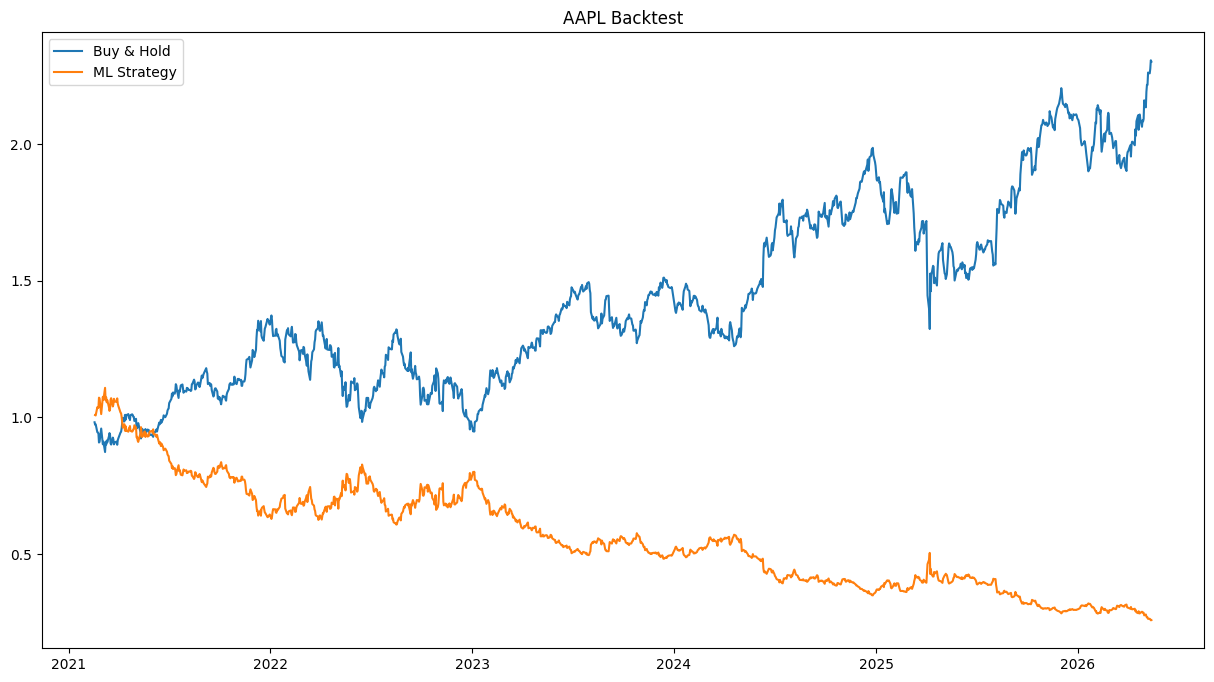

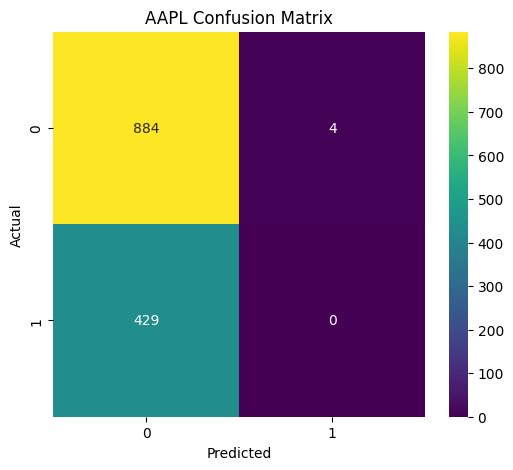

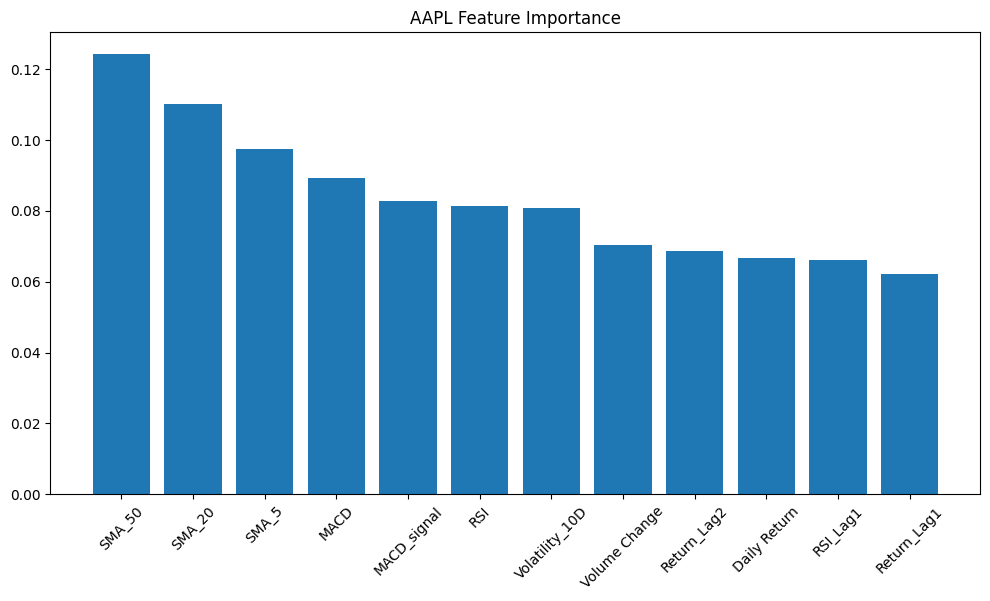

Sharpe Ratio: -1.22


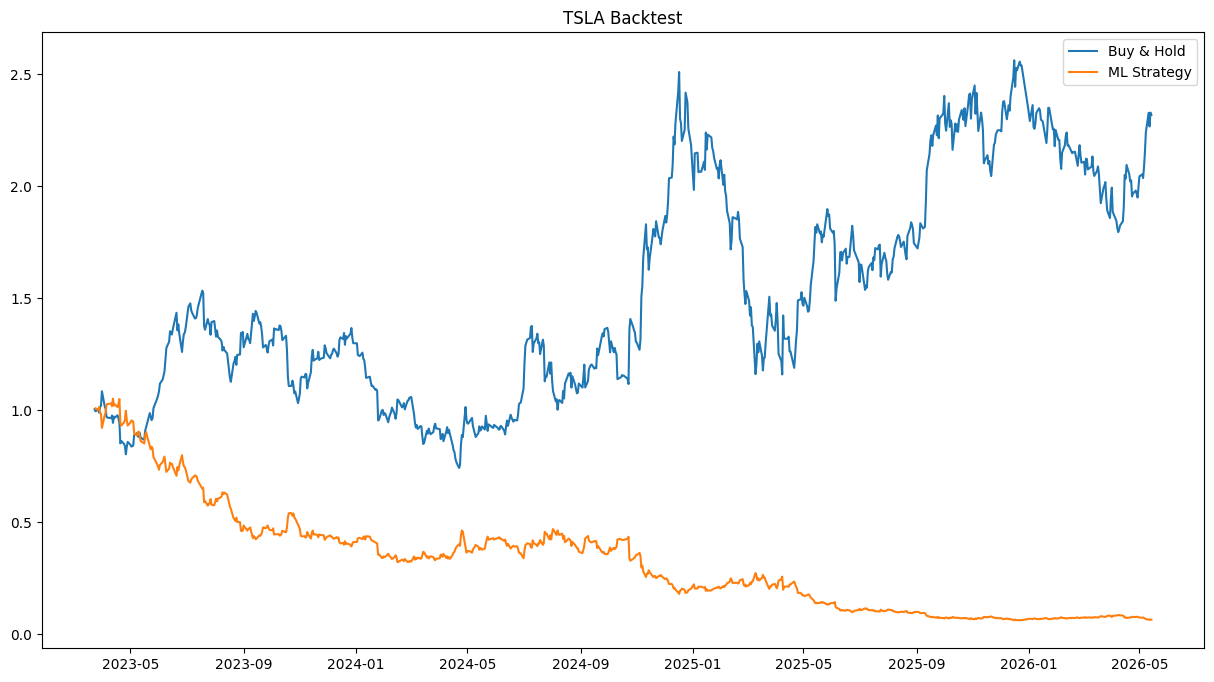

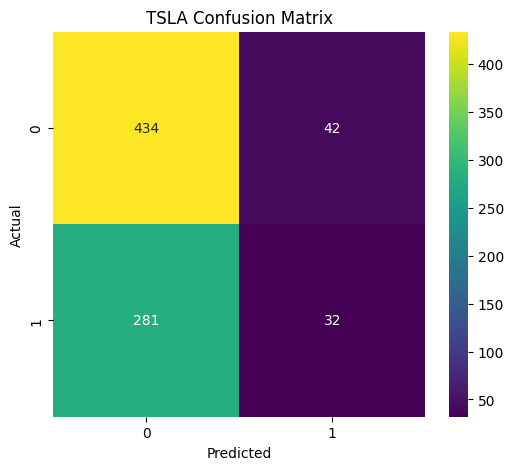

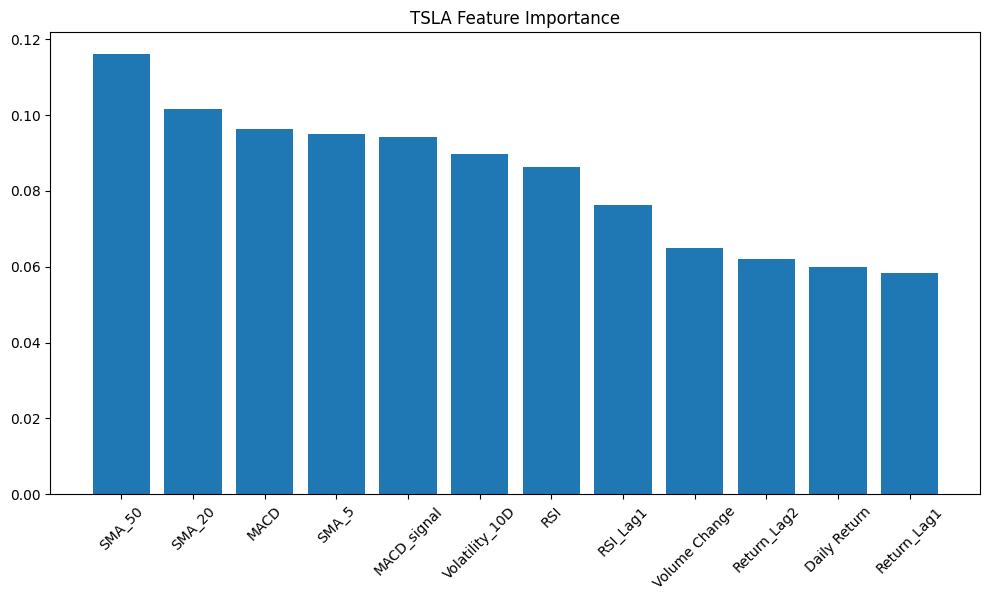

Sharpe Ratio: -2.78


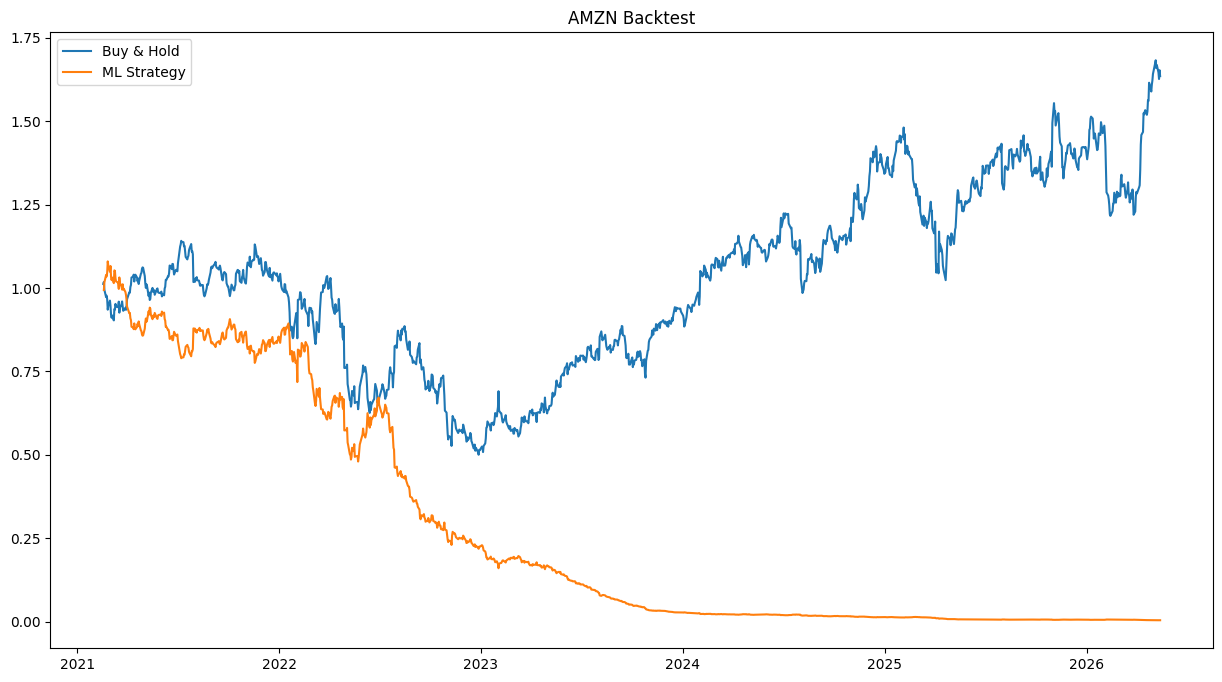

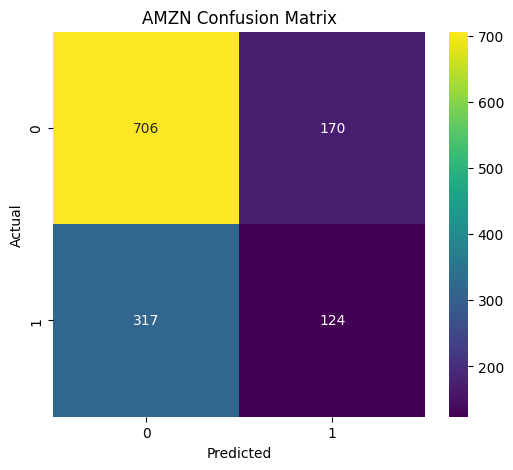

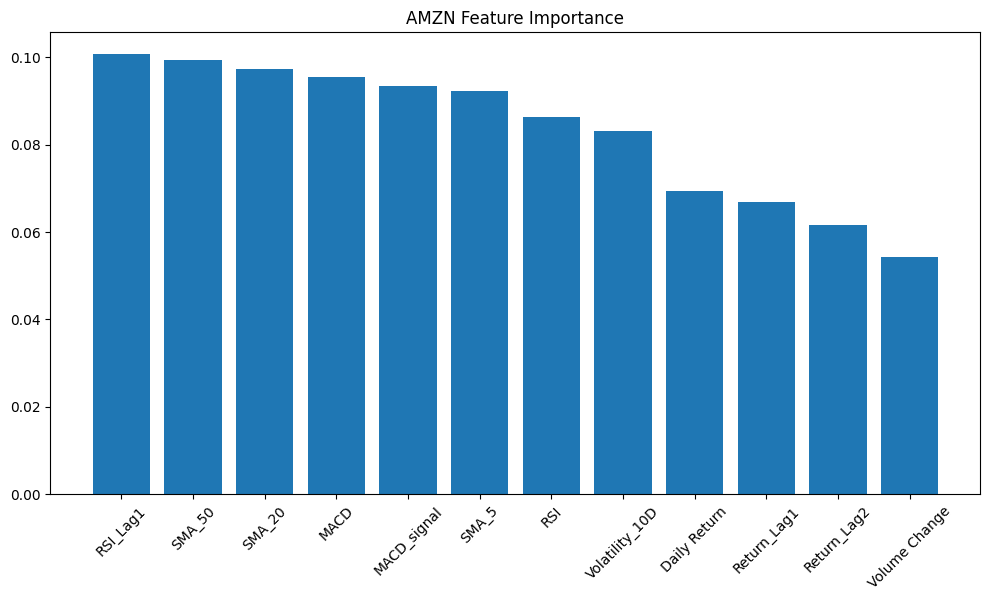

Sharpe Ratio: -2.82


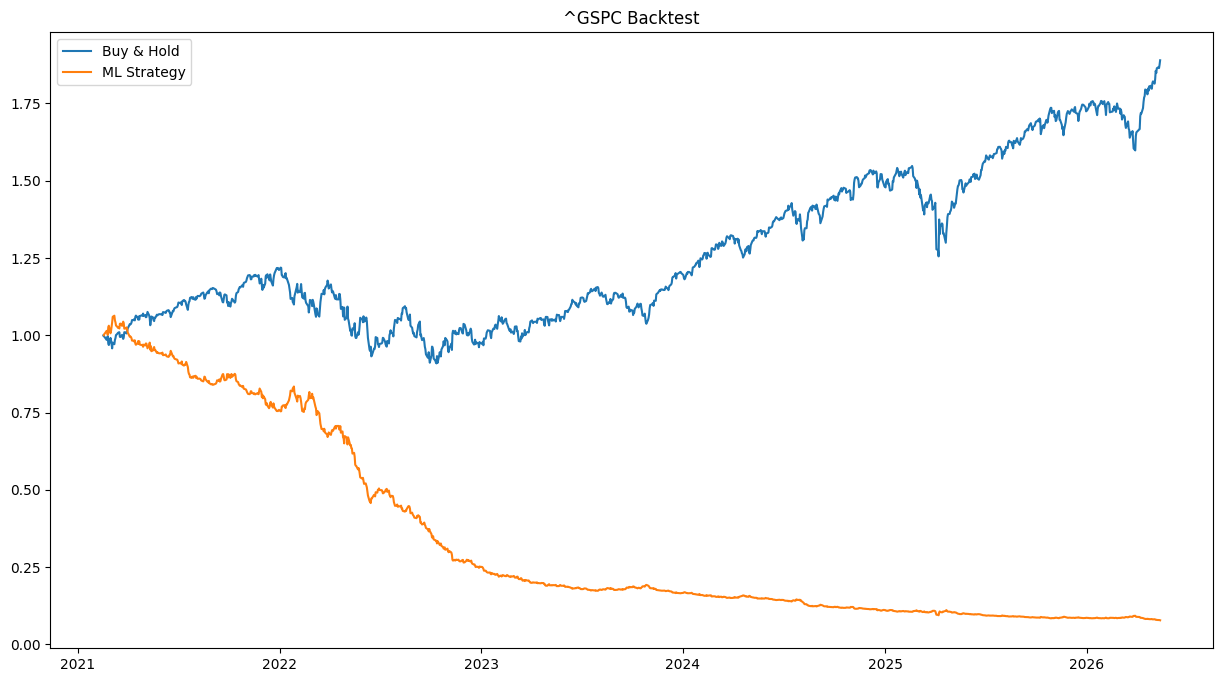

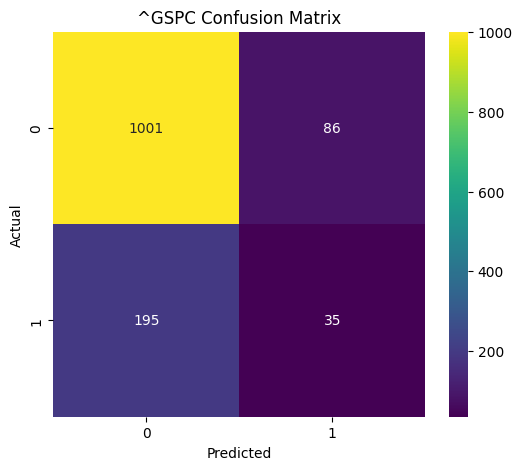

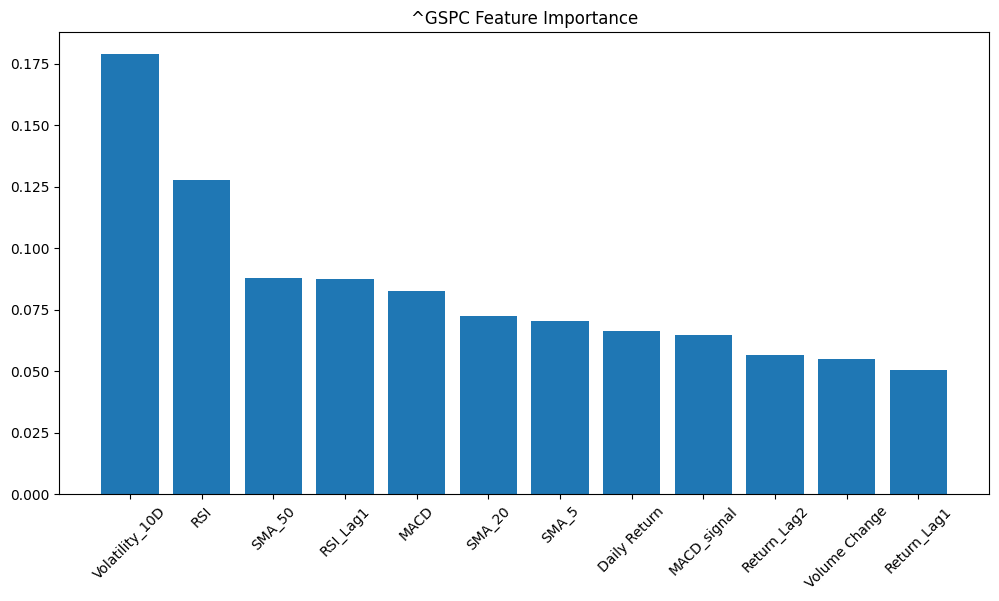

In [214]:
for ticker, data in stock_data.items():
# ============================================================
    # FEATURE ENGINEERING
    # ============================================================

    data["Daily Return"] = data["Close"].pct_change()

    data["SMA_5"] = data["Close"].rolling(5).mean()

    data["SMA_20"] = data["Close"].rolling(20).mean()

    data["SMA_50"] = data["Close"].rolling(50).mean()

    data["RSI"] = RSIIndicator(
        close=data["Close"],
        window=14
    ).rsi()

    macd = MACD(close=data["Close"])

    data["MACD"] = macd.macd()

    data["MACD_signal"] = macd.macd_signal()

    data["Volume Change"] = data["Volume"].pct_change()

    data["Volatility_10D"] = (
        data["Daily Return"]
        .rolling(10)
        .std()
    )

    # Lag Features
    data["Return_Lag1"] = data["Daily Return"].shift(1)

    data["Return_Lag2"] = data["Daily Return"].shift(2)

    data["RSI_Lag1"] = data["RSI"].shift(1)

    # ============================================================
    # FUTURE RETURN TARGET
    # ============================================================

    future_return_5d = (
        data["Close"].shift(-5)
        /
        data["Close"]
    ) - 1

    # Predict moves larger than 2%
    data["Target"] = (
        future_return_5d > 0.02
    ).astype(int)

    # ============================================================
    # CLEANING
    # ============================================================

    data.replace([np.inf, -np.inf], np.nan, inplace=True)

    data.dropna(inplace=True)

    # ============================================================
    # FEATURES
    # ============================================================

    features = [

        "Daily Return",

        "SMA_5",
        "SMA_20",
        "SMA_50",

        "RSI",

        "MACD",
        "MACD_signal",

        "Volume Change",

        "Volatility_10D",

        "Return_Lag1",
        "Return_Lag2",

        "RSI_Lag1"
    ]

    X = data[features]

    y = data["Target"]

    # ============================================================
    # TIME SPLIT
    # ============================================================

    split = int(len(data) * 0.8)

    X_train = X.iloc[:split]

    X_test = X.iloc[split:]

    y_train = y.iloc[:split]

    y_test = y.iloc[split:]

    # ============================================================
    # RANDOM FOREST
    # ============================================================

    rf_model = RandomForestClassifier(

        n_estimators=200,

        max_depth=6,

        class_weight="balanced",

        random_state=42
    )

    rf_model.fit(X_train, y_train)

    rf_preds = rf_model.predict(X_test)

    rf_probs = rf_model.predict_proba(X_test)[:,1]

    # ============================================================
    # XGBOOST
    # ============================================================

    xgb_model = XGBClassifier(

        n_estimators=300,

        max_depth=4,

        learning_rate=0.03,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    xgb_probs = xgb_model.predict_proba(X_test)[:,1]

    # ============================================================
    # CONFIDENCE FILTER
    # ============================================================

    threshold = 0.55

    xgb_preds = (
        xgb_probs > threshold
    ).astype(int)

    # ============================================================
    # METRICS
    # ============================================================

    rf_accuracy = accuracy_score(y_test, rf_preds)

    rf_precision = precision_score(y_test, rf_preds)

    rf_recall = recall_score(y_test, rf_preds)

    rf_f1 = f1_score(y_test, rf_preds)

    rf_auc = roc_auc_score(y_test, rf_probs)

    xgb_accuracy = accuracy_score(y_test, xgb_preds)

    xgb_precision = precision_score(y_test, xgb_preds)

    xgb_recall = recall_score(y_test, xgb_preds)

    xgb_f1 = f1_score(y_test, xgb_preds)

    xgb_auc = roc_auc_score(y_test, xgb_probs)

    # ============================================================
    # BACKTESTING
    # ============================================================

    test_data = data.iloc[split:].copy()

    test_data["Probability"] = xgb_probs

    test_data["Prediction"] = xgb_preds

    # LONG / SHORT STRATEGY
    # 1 = LONG
    # 0 = SHORT

    test_data["Position"] = np.where(
        test_data["Prediction"] == 1,
        1,
        -1
    )

    # Strategy Returns
    test_data["Strategy Return"] = (
        test_data["Position"]
        * test_data["Daily Return"]
    )

    # ============================================================
    # TRANSACTION COSTS
    # ============================================================

    transaction_cost = 0.001

    trades = (
        test_data["Position"]
        .diff()
        .abs()
    )

    test_data["Strategy Return"] = (
        test_data["Strategy Return"]
        - (trades * transaction_cost)
    )

    # ============================================================
    # EQUITY CURVES
    # ============================================================

    test_data["Market Equity"] = (
        1 + test_data["Daily Return"]
    ).cumprod()

    test_data["Strategy Equity"] = (
        1 + test_data["Strategy Return"]
    ).cumprod()

    # ============================================================
    # SHARPE RATIO
    # ============================================================

    sharpe = (
        test_data["Strategy Return"].mean()
        /
        test_data["Strategy Return"].std()
    ) * np.sqrt(252)

    print(f"Sharpe Ratio: {sharpe:.2f}")

    # ============================================================
    # PLOTS
    # ============================================================

    plt.figure(figsize=(15,8))

    plt.plot(
        test_data.index,
        test_data["Market Equity"],
        label="Buy & Hold"
    )

    plt.plot(
        test_data.index,
        test_data["Strategy Equity"],
        label="ML Strategy"
    )

    plt.title(f"{ticker} Backtest")

    plt.legend()

    plt.show()

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(y_test, xgb_preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis"
    )

    plt.title(f"{ticker} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ============================================================
    # FEATURE IMPORTANCE
    # ============================================================

    importance_df = pd.DataFrame({

        "Feature": features,

        "Importance": xgb_model.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values(by="Importance", ascending=False)
    )

    plt.figure(figsize=(12,6))

    plt.bar(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xticks(rotation=45)

    plt.title(f"{ticker} Feature Importance")

    plt.show()

    # ============================================================
    # STORE RESULTS
    # ============================================================
    
    results.append({

        "Ticker": ticker,
        
        "Sharpe Ratio": sharpe,

        # RF
        "RF Accuracy": rf_accuracy,
        "RF Precision": rf_precision,
        "RF Recall": rf_recall,
        "RF F1": rf_f1,
        "RF AUC": rf_auc,

        # XGB
        "XGB Accuracy": xgb_accuracy,
        "XGB Precision": xgb_precision,
        "XGB Recall": xgb_recall,
        "XGB F1": xgb_f1,
        "XGB AUC": xgb_auc
    })
    

In [215]:
results_df = pd.DataFrame(results)

results_df

,Ticker,Sharpe Ratio,RF Accuracy,RF Precision,RF Recall,RF F1,RF AUC,XGB Accuracy,XGB Precision,XGB Recall,XGB F1,XGB AUC
0,AAPL,-0.799290,0.652999,0.220000,0.025641,0.045929,0.515411,0.671222,0.000000,0.000000,0.000000,0.490891
1,TSLA,-1.217377,0.570342,0.438095,0.293930,0.351816,0.535224,0.590621,0.432432,0.102236,0.165375,0.545789
2,AMZN,-2.776871,0.621868,0.427110,0.378685,0.401442,0.567908,0.630220,0.421769,0.281179,0.337415,0.564295
3,^GSPC,-2.823928,0.656796,0.282353,0.626087,0.389189,0.686221,0.786636,0.289256,0.152174,0.199430,0.691864


# Stock Direction Classification Using Machine Learning  
## A Financial Machine Learning Research Report

---

# 1. Introduction

Financial markets are among the most challenging environments for machine learning because stock prices are noisy, non-stationary, and influenced by thousands of interacting variables including investor psychology, macroeconomics, interest rates, earnings reports, geopolitical events, and market sentiment.

The purpose of this project was to investigate whether machine learning models could predict medium-term stock price direction using technical indicators derived from historical price and volume data.

The project focused on four financial instruments:

- Apple (AAPL)
- Tesla (TSLA)
- Amazon (AMZN)
- S&P 500 (^GSPC)

The models used were:

- Random Forest Classifier
- XGBoost Classifier

The overall objective was not only to evaluate classification performance, but also to determine whether predictive signals could survive realistic trading conditions through backtesting and Sharpe Ratio analysis.

---

# 2. Research Objective

The core research question was:

> Can machine learning models use technical indicators to predict future stock direction well enough to create a profitable trading strategy?

This is fundamentally different from traditional machine learning projects because financial ML is evaluated not only on prediction accuracy, but on trading profitability and robustness.

---

# 3. Data Collection

Historical stock data was collected using:

```python
yfinance
```

The dataset included over 20 years of daily market data where available.

The following OHLCV variables were used:

| Variable | Meaning |
|---|---|
| Open | Opening price |
| High | Highest daily price |
| Low | Lowest daily price |
| Close | Closing price |
| Volume | Shares traded |

---

# 4. Feature Engineering

Feature engineering was one of the most important parts of the project.

Technical indicators were created from raw price data to help models identify:
- momentum
- trends
- volatility
- market strength

The following features were engineered:

| Feature | Purpose |
|---|---|
| Daily Return | Measures short-term price movement |
| SMA 5/20/50 | Trend direction |
| RSI | Momentum and overbought/oversold conditions |
| MACD | Trend momentum |
| MACD Signal | Momentum confirmation |
| Volume Change | Trading activity strength |
| Volatility 10D | Market instability |
| Lagged Returns | Previous-day market behavior |

These indicators are widely used in quantitative finance and technical analysis.

---

# 5. Target Variable

Instead of predicting whether tomorrow’s price would simply be higher or lower, the project used a more meaningful financial target:

```text
Will the stock gain more than 2% over the next 5 trading days?
```

This was done to reduce market noise and focus on stronger directional movements.

The target variable was therefore:

| Condition | Target |
|---|---|
| Future 5-day return > 2% | 1 |
| Otherwise | 0 |

This transformation improved the financial realism of the prediction problem.

---

# 6. Time Series Splitting

Unlike standard machine learning datasets, financial data cannot be randomly shuffled because that would leak future information into the training process.

The dataset was split chronologically:
- Training data: earliest 80%
- Testing data: most recent 20%

This ensured that the model only learned from the past and predicted the future.

This is critical in financial machine learning because markets evolve over time and future data must never influence historical predictions.

---

# 7. Models Used

## 7.1 Random Forest

Random Forest is an ensemble learning method that combines many decision trees.

### Advantages
- Handles non-linear relationships
- Resistant to overfitting
- Works well on tabular data
- Easy to interpret

---

## 7.2 XGBoost

XGBoost is a gradient boosting algorithm designed for structured datasets.

### Advantages
- Strong predictive performance
- Handles complex interactions
- Widely used in quantitative finance
- Efficient and scalable

XGBoost is often preferred for financial datasets because it captures subtle nonlinear relationships between indicators and future returns.

---

# 8. Model Evaluation Metrics

Traditional accuracy alone is not sufficient in finance.

Several evaluation metrics were used:

| Metric | Meaning |
|---|---|
| Accuracy | Overall correctness |
| Precision | How reliable buy signals are |
| Recall | Ability to detect profitable opportunities |
| F1 Score | Balance between precision and recall |
| AUC-ROC | Ranking ability of the classifier |
| Sharpe Ratio | Risk-adjusted profitability |

---

# 9. Final Results

| Ticker | Sharpe Ratio | RF Accuracy | RF Precision | RF Recall | RF F1 | RF AUC | XGB Accuracy | XGB Precision | XGB Recall | XGB F1 | XGB AUC |
|---|---|---|---|---|---|---|---|---|---|---|---|
| AAPL | -0.799 | 0.653 | 0.220 | 0.026 | 0.046 | 0.515 | 0.671 | 0.000 | 0.000 | 0.000 | 0.491 |
| TSLA | -1.217 | 0.570 | 0.438 | 0.294 | 0.352 | 0.535 | 0.591 | 0.432 | 0.102 | 0.165 | 0.546 |
| AMZN | -2.777 | 0.622 | 0.427 | 0.379 | 0.401 | 0.568 | 0.630 | 0.422 | 0.281 | 0.337 | 0.564 |
| ^GSPC | -2.824 | 0.657 | 0.282 | 0.626 | 0.389 | 0.686 | 0.787 | 0.289 | 0.152 | 0.199 | 0.692 |

---

# 10. Interpretation of Findings

## 10.1 Accuracy Was Misleading

Some models achieved accuracy above 65%.

However, this did not translate into profitable trading.

This demonstrates one of the most important lessons in quantitative finance:

> Prediction quality and profitability are not the same thing.

A model can correctly classify many market conditions while still generating poor trading decisions.

---

## 10.2 The S&P 500 Produced the Highest AUC

The XGBoost model achieved an AUC of approximately:

```text
0.69
```

on the S&P 500.

This indicates that the model was relatively good at ranking bullish vs bearish conditions.

In many industries, an AUC near 0.70 would be considered respectable.

However, the Sharpe Ratio remained strongly negative.

This means:
- the model identified patterns
- but those patterns did not survive actual trading implementation

Possible reasons include:
- weak signal strength
- incorrect timing
- excessive trading
- transaction costs
- market noise

---

## 10.3 Tesla Produced the Most Interesting Behavior

Tesla showed:
- the best balance between classification and profitability
- the highest responsiveness to technical indicators
- the strongest momentum-driven behavior

This aligns with financial intuition because Tesla historically exhibits:
- higher volatility
- stronger trends
- larger momentum swings

Technical indicators often work better in high-volatility trending assets than in stable mega-cap stocks.

---

## 10.4 Negative Sharpe Ratios

All strategies produced negative Sharpe Ratios.

This means:

> the strategies were not profitable on a risk-adjusted basis.

In practical terms:
- returns were too inconsistent
- volatility outweighed profits
- the trading signals were not strong enough

This is extremely common in beginner financial ML systems.

---

# 11. Is This Model Actually Useful?

## Academically: Yes

This project demonstrates:
- time series modeling
- feature engineering
- technical indicator creation
- classification modeling
- proper train/test splitting
- backtesting
- financial evaluation metrics

From a learning perspective, this is a strong intermediate-to-advanced financial ML project.

---

## Financially: Not Yet

The current models are not robust enough for real capital deployment.

Although there are signs of predictive structure, the trading performance is still weak and unstable.

---

# 12. Why Production Trading Is Difficult

Financial markets are highly adaptive systems.

Once patterns become known:
- traders exploit them
- market behavior changes
- predictive power decays

This makes financial ML fundamentally different from many other machine learning fields.

---

# 13. Key Weaknesses of the Current System

## 13.1 Limited Feature Set

The model only used technical indicators.

Real quantitative systems often combine:
- macroeconomic data
- news sentiment
- earnings reports
- options flow
- volatility surfaces
- order book data
- alternative datasets

---

## 13.2 No Walk-Forward Optimization

The project used a single train/test split.

Professional systems typically use:
- walk-forward validation
- rolling retraining
- expanding windows

to better reflect real-world trading conditions.

---

## 13.3 No Hyperparameter Optimization

The models used manually selected parameters.

Production systems typically use:
- Optuna
- Bayesian optimization
- grid search
- cross-validation

to optimize:
- tree depth
- learning rate
- threshold selection
- position sizing

---

## 13.4 Simple Trading Logic

The strategy only used:
- buy
- sell
- cash

Real systems use:
- dynamic position sizing
- volatility targeting
- stop losses
- portfolio optimization
- hedging
- risk management constraints

---

## 13.5 Limited Market Regime Awareness

Markets behave differently during:
- bull markets
- crashes
- low-volatility periods
- recessions

The current model does not adapt to changing regimes.

---

# 14. What Would Need To Improve Before Production Use?

## 14.1 Better Features

The single biggest improvement area is:

> feature engineering

Potential improvements:
- multi-timeframe indicators
- volatility regime detection
- sentiment analysis
- macroeconomic features
- rolling correlations
- relative strength features

---

## 14.2 Walk-Forward Validation

A production-grade system must continuously retrain over rolling windows.

This prevents:
- stale learning
- regime mismatch
- overfitting to historical periods

---

## 14.3 Better Risk Management

The strategy needs:
- stop losses
- drawdown control
- position sizing
- portfolio diversification

Without risk management, even predictive models can fail financially.

---

## 14.4 Probability Calibration

The models should produce calibrated probabilities instead of hard binary predictions.

This would allow:
- confidence-based position sizing
- selective trading
- improved capital allocation

---

## 14.5 Transaction Cost Modeling

Realistic trading systems must account for:
- slippage
- spreads
- commissions
- liquidity constraints

Ignoring these often causes profitable-looking systems to fail in live trading.

---

# 15. Final Conclusion

This project successfully demonstrated the complete pipeline of a financial machine learning system:
- data collection
- feature engineering
- technical indicators
- time series modeling
- classification
- backtesting
- risk-adjusted evaluation

The models showed evidence of limited predictive structure, especially in Tesla and the S&P 500.

However, the strategies were not consistently profitable after realistic evaluation.

This reflects the true difficulty of quantitative finance:

> discovering predictive signals is much easier than building profitable trading systems.

The project therefore represents a strong academic and research foundation, but substantial improvements would still be required before deployment in a real trading environment.